# Parte 0 - CNN para imagenes a color
Hecho por Samuel Patiño y Nicolás Peña - IA Generativa UAO

El enunciado de la Parte 0 pide dos cosas:

1. Investigar como implementar redes neuronales convolucionales para imagenes a color.
2. Enfocar la investigacion en metodos de carga y preprocesamiento de imagenes.

Este cuaderno es la respuesta a esa parte. No entrena ningun modelo final: es la base que
despues usan los cuadernos 01 (CIFAR-10) y 02 (COVID). Todo el codigo de aca se puede correr
en Kaggle con GPU y Internet activados.

Lo que vamos a ver:

1. Que es una imagen a color vista como datos.
2. Espacios de color: RGB, escala de grises y CIE Lab.
3. Cuatro formas de cargar imagenes en TensorFlow.
4. Preprocesamiento: redimensionar, normalizar, tipos de datos, lotes y aumento de datos.
5. Como una capa Conv2D procesa los tres canales de color.
6. Una CNN minima para imagenes a color.
7. Como aplicamos todo esto a nuestro dataset de COVID.

## 1. Que es una imagen a color

Para la red, una imagen no es una foto: es un arreglo de numeros. Una imagen a color en RGB
es un tensor de tres dimensiones: alto, ancho y canales. Los tres canales son rojo, verde y
azul, y cada uno es una matriz con la intensidad de ese color en cada pixel.

Con blanco y negro seria (alto, ancho, 1). Con color es (alto, ancho, 3).

Cada pixel guarda un valor entre 0 y 255, donde 0 es ausencia total de ese color y 255 es la
intensidad maxima. Mezclando los tres canales se obtienen todos los colores.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("TensorFlow:", tf.__version__)

# CIFAR-10 viene con TensorFlow, son 60 mil imagenes a color de 32x32
(cifar_train, y_train), (cifar_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.flatten()

print("conjunto de train:", cifar_train.shape)
print("tipo de dato:", cifar_train.dtype)
print("rango de valores:", cifar_train.min(), "a", cifar_train.max())

img = cifar_train[0]
print()
print("una sola imagen:", img.shape, "-> (alto, ancho, canales)")

TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
conjunto de train: (50000, 32, 32, 3)
tipo de dato: uint8
rango de valores: 0 a 255

una sola imagen: (32, 32, 3) -> (alto, ancho, canales)


Si separamos los tres canales y los pintamos solos, se ve claramente que la imagen es la
suma de tres capas de intensidad. El canal rojo brilla donde la imagen tiene rojo, y asi con
cada uno.

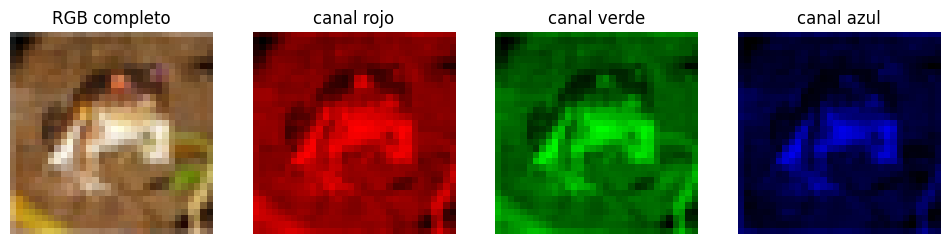

In [2]:
nombres = ["rojo", "verde", "azul"]
plt.figure(figsize=(12,3))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("RGB completo")
plt.axis("off")

for i in range(3):
    # dejamos un solo canal encendido y los otros en cero
    canal = np.zeros_like(img)
    canal[:,:,i] = img[:,:,i]
    plt.subplot(1,4,i+2)
    plt.imshow(canal)
    plt.title("canal " + nombres[i])
    plt.axis("off")

plt.show()

## 2. Espacios de color

RGB no es la unica forma de representar color. El paper de la carpeta
doc/CNN for Color Images (Qiu y otros, 2025) trabaja con el espacio CIE Lab, y conviene
saber por que.

- RGB: tres canales de color puro (rojo, verde, azul). Es lo que usamos nosotros y lo que
  espera Keras por defecto.
- Escala de grises: un solo canal. Se obtiene como promedio ponderado de los tres canales,
  porque el ojo humano no pesa igual los tres colores.
- CIE Lab: separa la luminosidad (canal L) del color (canales a y b). El paper lo usa porque
  asi la red solo tiene que predecir dos canales de color y la luminosidad ya la tiene dada.

Para nuestro examen trabajamos en RGB, que es lo que pide la Parte 0 y lo que usa el
profesor en sus cuadernos. Pero saber que Lab existe explica por que en el cuaderno 02
cargamos las radiografias (que son de escala de grises) como si fueran RGB: para que todas
las imagenes entren con la misma forma de tres canales.

I0000 00:00:1788716540.927076      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788716540.930108      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


RGB: (32, 32, 3) -> gris: (32, 32, 1)


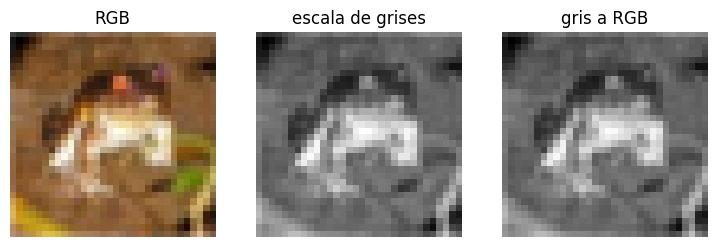

al repetir el canal, los tres valores de un pixel quedan iguales:
pixel central RGB: [245 237 226]  gris a RGB: [238.1135 238.1135 238.1135]


In [3]:
# convertimos a escala de grises con TensorFlow
gris = tf.image.rgb_to_grayscale(img.astype("float32"))
print("RGB:", img.shape, "-> gris:", gris.shape)

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); plt.imshow(img); plt.title("RGB"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(gris.numpy()[:,:,0], cmap="gray"); plt.title("escala de grises"); plt.axis("off")

# y de gris podemos volver a RGB repitiendo el canal tres veces
de_vuelta = tf.image.grayscale_to_rgb(gris)
plt.subplot(1,3,3); plt.imshow(de_vuelta.numpy().astype("uint8")); plt.title("gris a RGB"); plt.axis("off")
plt.show()

print("al repetir el canal, los tres valores de un pixel quedan iguales:")
print("pixel central RGB:", img[16,16], " gris a RGB:", de_vuelta.numpy()[16,16])

## 3. Formas de cargar imagenes

Hay cuatro caminos para meter imagenes a TensorFlow. Cual usar depende de donde esten las
imagenes y de cuanto control necesitemos sobre el proceso.

1. load_img: carga una imagen individual desde disco. Sirve para pruebas rapidas.
2. image_dataset_from_directory: lee una carpeta organizada por subcarpetas de clase. Es la
   mas comoda cuando el dataset ya viene asi, como el de COVID.
3. tf.data: da control total sobre la tuberia de datos. Se usa cuando hay que hacer
   transformaciones a medida.
4. Datasets integrados: keras.datasets trae CIFAR-10, MNIST y otros listos para usar.

Vamos a ver las cuatro.

### 3.1 Cargar una imagen individual con load_img

load_img abre la imagen con la libreria PIL y opcionalmente la redimensiona. img_to_array la
convierte en el arreglo de numeros que espera la red.

El parametro color_mode decide cuantos canales queremos: "rgb" para tres, "grayscale" para
uno, "rgba" para cuatro. Nosotros usamos "rgb".

In [4]:
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
import os

# guardamos una imagen de CIFAR en disco para poder demostrar la carga
os.makedirs("/tmp/demo", exist_ok=True)
Image.fromarray(cifar_train[0]).save("/tmp/demo/ejemplo.png")

# la cargamos pidiendo un tamaño fijo de 64x64 y tres canales
img_cargada = load_img("/tmp/demo/ejemplo.png", target_size=(64,64), color_mode="rgb")
arreglo = img_to_array(img_cargada)

print("objeto PIL:", type(img_cargada).__name__, "tamaño:", img_cargada.size)
print("arreglo:", arreglo.shape, arreglo.dtype)
print("rango:", arreglo.min(), "a", arreglo.max())

# si la pidieramos en gris, saldria con un solo canal
img_gris = load_img("/tmp/demo/ejemplo.png", target_size=(64,64), color_mode="grayscale")
print("en gris:", img_to_array(img_gris).shape)

objeto PIL: Image tamaño: (64, 64)
arreglo: (64, 64, 3) float32
rango: 0.0 a 255.0
en gris: (64, 64, 1)


### 3.2 Leer una carpeta por clases con image_dataset_from_directory

Cuando el dataset esta organizado en carpetas, una por clase, esta funcion hace todo el
trabajo: recorre las carpetas, infiere las etiquetas del nombre de cada carpeta, redimensiona
y arma los lotes.

El dataset de COVID tiene justo esa estructura:

    Covid19-dataset/
        train/
            Covid/
            Normal/
            Viral Pneumonia/
        test/
            Covid/
            Normal/
            Viral Pneumonia/

Para que esta celda se pueda correr sin descargar nada, armamos una carpeta chiquita con la
misma estructura usando imagenes de CIFAR.

In [5]:
# armamos una carpeta de prueba con dos clases
base_tmp = "/tmp/demo_dataset"
for clase in ["clase_a", "clase_b"]:
    os.makedirs(os.path.join(base_tmp, clase), exist_ok=True)
for i in range(6):
    Image.fromarray(cifar_train[i]).save(f"{base_tmp}/clase_a/img{i}.png")
    Image.fromarray(cifar_train[i+10]).save(f"{base_tmp}/clase_b/img{i}.png")

ds = tf.keras.utils.image_dataset_from_directory(
    base_tmp,
    labels="inferred",        # las etiquetas salen del nombre de la carpeta
    label_mode="categorical", # one-hot, util para clasificacion de varias clases
    color_mode="rgb",
    image_size=(64, 64),      # redimensiona todo al mismo tamaño
    batch_size=4,
)

print("clases encontradas:", ds.class_names)
for lote_x, lote_y in ds.take(1):
    print("lote de imagenes:", lote_x.shape, lote_x.dtype)
    print("lote de etiquetas:", lote_y.shape)

Found 12 files belonging to 2 classes.
clases encontradas: ['clase_a', 'clase_b']
lote de imagenes: (4, 64, 64, 3) <dtype: 'float32'>
lote de etiquetas: (4, 2)


### 3.3 Control total con tf.data

image_dataset_from_directory devuelve un objeto tf.data.Dataset. Eso significa que le podemos
encadenar transformaciones con map, y asi hacer exactamente el preprocesamiento que queramos.

Dos detalles importantes:

- convert_image_dtype pasa de enteros de 8 bits a float32 y de paso divide entre 255, dejando
  los valores entre 0 y 1. Es la forma correcta de normalizar dentro de una tuberia.
- prefetch prepara el siguiente lote mientras la red procesa el actual, lo que evita que la
  GPU se quede esperando al disco.

In [6]:
def preparar(x, y):
    # de uint8 en [0,255] a float32 en [0,1]
    x = tf.image.convert_image_dtype(x, tf.float32)
    # por si queremos otro tamaño
    x = tf.image.resize(x, (64, 64))
    return x, y

ds_procesado = ds.map(preparar).prefetch(tf.data.AUTOTUNE)

for lote_x, lote_y in ds_procesado.take(1):
    print("imagenes:", lote_x.shape, lote_x.dtype)
    print("rango:", float(tf.reduce_min(lote_x)), "a", float(tf.reduce_max(lote_x)))
    print("etiquetas:", lote_y.shape)

imagenes: (4, 64, 64, 3) <dtype: 'float32'>
rango: 0.5 a 252.4375
etiquetas: (4, 2)


### 3.4 Datasets integrados

Para CIFAR-10 y MNIST no hace falta descargar nada a mano: vienen con Keras. Es lo que usa el
cuaderno 01 y lo que usa el profesor en la semana 5.

La ventaja es que ya vienen separados en train y test y en el formato correcto. La desventaja
es que no sirven para datos propios, como las radiografias.

In [7]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.cifar10.load_data()

print("train:", x_tr.shape, x_tr.dtype, "rango", x_tr.min(), "-", x_tr.max())
print("test: ", x_te.shape, x_te.dtype)
print("etiquetas train:", y_tr.shape, "clases:", len(np.unique(y_tr)))

# las etiquetas vienen como columna de numeros del 0 al 9
print("primeras diez etiquetas:", y_tr[:10].flatten())

train: (50000, 32, 32, 3) uint8 rango 0 - 255
test:  (10000, 32, 32, 3) uint8
etiquetas train: (50000, 1) clases: 10
primeras diez etiquetas: [6 9 9 4 1 1 2 7 8 3]


## 4. Preprocesamiento

Cargar es solo la mitad del trabajo. Antes de entrar a la red, las imagenes necesitan cuatro
transformaciones. Saltarse alguna de estas es la causa mas comun de que un modelo no aprenda.

### 4.1 Dejar todas las imagenes del mismo tamaño

Una red convolucional con capas densas al final necesita que todas las entradas tengan la
misma forma. Si una imagen mide 300x200 y otra 150x150, no se pueden poner en el mismo lote.

La solucion es redimensionar todo a un tamaño fijo. Nosotros usamos 64x64 en el cuaderno 02 y
32x32 en el 01 (que es el tamaño nativo de CIFAR-10).

original: (32, 32, 3) -> chica: (16, 16, 3) -> grande: (64, 64, 3)


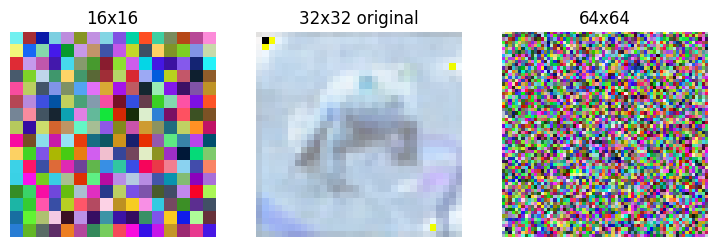

In [8]:
# redimensionamos una imagen de 32x32 a 16x16 y a 64x64
original = img.astype("float32")
chica = tf.image.resize(original, (16, 16))
grande = tf.image.resize(original, (64, 64))

print("original:", original.shape, "-> chica:", chica.shape, "-> grande:", grande.shape)

plt.figure(figsize=(9,3))
for i, (titulo, ar) in enumerate([("16x16", chica), ("32x32 original", original), ("64x64", grande)]):
    plt.subplot(1,3,i+1)
    plt.imshow(tf.image.convert_image_dtype(ar, tf.uint8).numpy())
    plt.title(titulo); plt.axis("off")
plt.show()

### 4.2 Normalizar los valores

Los pixeles vienen como enteros entre 0 y 255. A las redes les cuesta trabajar con numeros en
ese rango, sobre todo porque los pesos arrancan siendo valores pequenos. La solucion es
dividir entre 255 para dejar todo entre 0 y 1.

Esto no es opcional. Sin normalizar, el entrenamiento se vuelve inestable y tarda mucho mas
en converger.

Un detalle que conviene recordar para la exposicion: la ultima capa del decoder usa
activacion sigmoid, que justamente devuelve valores entre 0 y 1. Por eso normalizar la entrada
es coherente con usar sigmoid a la salida.

In [9]:
x = cifar_train.astype("float32")
print("antes de normalizar:", x.min(), "a", x.max())

x_norm = x / 255.0
print("despues de normalizar:", x_norm.min(), "a", x_norm.max())

# la misma cuenta con TensorFlow, que es lo que se usa dentro de una tuberia
x_tf = tf.image.convert_image_dtype(cifar_train, tf.float32)
print("con convert_image_dtype:", float(tf.reduce_min(x_tf)), "a", float(tf.reduce_max(x_tf)))

antes de normalizar: 0.0 a 255.0
despues de normalizar: 0.0 a 1.0
con convert_image_dtype: 0.0 a 1.0


### 4.3 Tipos de datos y lotes

Las imagenes crudas vienen como uint8 (enteros de 8 bits, 0 a 255). Despues de normalizar
deben quedar como float32.

El lote (batch) es la cantidad de imagenes que la red procesa de una sola vez. Un lote de 32
significa que la red ve 32 imagenes, promedia el error de las 32 y recien ahi ajusta los
pesos. El tamaño del lote es un hiperparametro: lotes chicos entrenan mas lento pero
generalizan mejor con pocos datos, lotes grandes aprovechan mejor la GPU.

In [10]:
print("uint8 ocupa:", cifar_train.nbytes / 1e6, "MB")
print("float32 ocupa:", x_norm.nbytes / 1e6, "MB")

# armamos lotes a mano para ver como cambia la forma
lote = x_norm[:32]
print()
print("una imagen:", x_norm[0].shape)
print("un lote de 32:", lote.shape, "-> (cantidad, alto, ancho, canales)")

uint8 ocupa: 153.6 MB
float32 ocupa: 614.4 MB

una imagen: (32, 32, 3)
un lote de 32: (32, 32, 32, 3) -> (cantidad, alto, ancho, canales)


### 4.4 Aumento de datos

Con pocas imagenes, la red memoriza en lugar de aprender. El aumento de datos consiste en
crear variantes artificiales de cada imagen: voltearla, rotarla, acercarla. La red ve mas
ejemplos de los que realmente hay.

Esto importa mucho en nuestro caso: el dataset de COVID tiene 251 imagenes de train, que son
muy pocas. En el cuaderno 02 exploramos justamente esta idea con el experimento de parches y
el de ruido fresco.

En TensorFlow se puede hacer con capas de aumento puestas al principio del modelo. Solo se
aplican durante el entrenamiento, nunca al evaluar.

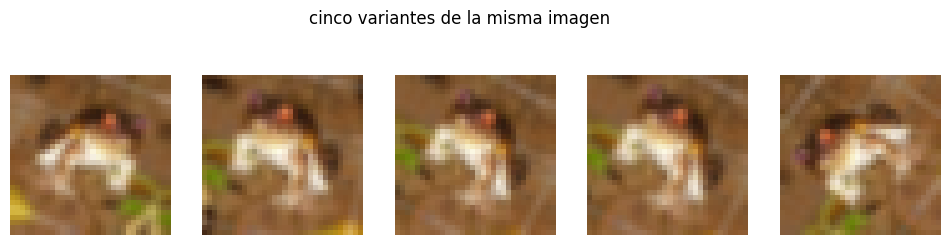

In [11]:
capas_aumento = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
])

ejemplo = tf.expand_dims(x_norm[0], 0)  # agregamos la dimension del lote

plt.figure(figsize=(12,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(capas_aumento(ejemplo, training=True)[0])
    plt.axis("off")
plt.suptitle("cinco variantes de la misma imagen")
plt.show()

## 5. Como una Conv2D procesa el color

Esta es la parte conceptual de la Parte 0. Una capa convolucional no mira la imagen de a tres
canales por separado: aplica filtros que mezclan los tres.

Un filtro de 3x3 sobre una imagen a color en realidad es de 3x3x3: tres filas, tres columnas
y tres canales de profundidad. Cada filtro recorre la imagen y produce un numero por posicion,
que es la suma ponderada de los 27 valores que cubre.

Si la capa tiene 32 filtros, la salida tiene 32 canales. Cada filtro aprende a detectar algo
distinto: uno bordes verticales, otro texturas, otro cambios de color.

La cuenta de parametros es:

    (alto_filtro * ancho_filtro * canales_entrada * cantidad_filtros) + cantidad_filtros

El ultimo termino son los sesgos, uno por filtro.

In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

entrada = Input(shape=(32, 32, 3))
salida = Conv2D(32, (3,3), activation="relu", padding="same")(entrada)
modelo_conv = Model(entrada, salida)

print("entrada:", entrada.shape, " salida:", salida.shape)
print()
print("parametros esperados: (3*3*3)*32 + 32 =", (3*3*3)*32 + 32)
modelo_conv.summary()

entrada: (None, 32, 32, 3)  salida: (None, 32, 32, 32)

parametros esperados: (3*3*3)*32 + 32 = 896


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

Fijarse que la cantidad de parametros no depende del tamaño de la imagen. Un filtro de 3x3x3
tiene los mismos 27 pesos sin importar si la imagen mide 32x32 o 1024x1024. Eso se llama
compartir pesos, y es la razon por la que las convoluciones son eficientes para imagenes.

## 6. Una CNN minima para imagenes a color

Juntando todo: una red que recibe imagenes de 32x32x3 y predice una de diez clases.

La estructura es siempre la misma:

1. Bloques de convolucion que van extrayendo caracteristicas.
2. MaxPooling que va reduciendo el tamaño espacial.
3. Flatten que aplana todo a un vector.
4. Capas densas que hacen la clasificacion final.

Esta es la misma logica que usa el autoencoder del cuaderno 01, solo que en lugar de
reconstruir la imagen, aca la salida es una clase.

In [13]:
modelo = tf.keras.Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, 3, activation="relu", padding="same"),
    MaxPooling2D(),                              # 32x32 -> 16x16
    Conv2D(64, 3, activation="relu", padding="same"),
    MaxPooling2D(),                              # 16x16 -> 8x8
    Conv2D(64, 3, activation="relu", padding="same"),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),             # diez clases de CIFAR-10
])

modelo.compile(optimizer="adam",
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Como lo aplicamos a nuestro dataset de COVID

En el cuaderno 02 usamos el patron de carga manual: recorrer las carpetas con load_img,
redimensionar a 64x64, pedir tres canales y normalizar dividiendo entre 255.

La funcion es esta, y aca la probamos sobre la carpeta de prueba para que se vea funcionando.
En el cuaderno 02 es exactamente la misma pero apuntando a las carpetas del dataset de COVID.

Dos decisiones que conviene poder justificar en la exposicion:

- Por que 64x64: es un compromiso. Mas chico pierde detalle de la radiografia, mas grande
  hace el modelo mas lento y con 251 imagenes no hay datos suficientes para llenarlo.
- Por que rgb si las radiografias son grises: porque la Parte 0 pide trabajar con imagenes a
  color y porque asi reutilizamos la misma arquitectura del profesor sin cambiar la forma de
  entrada.

In [14]:
def cargar_manual(carpeta, size=64):
    """recorre una carpeta con subcarpetas por clase y devuelve imagenes y etiquetas"""
    xs, ys = [], []
    clases = sorted(os.listdir(carpeta))
    mapa = {c: i for i, c in enumerate(clases)}
    for c in clases:
        ruta_clase = os.path.join(carpeta, c)
        for f in os.listdir(ruta_clase):
            try:
                img = load_img(os.path.join(ruta_clase, f),
                               target_size=(size, size), color_mode="rgb")
                xs.append(img_to_array(img) / 255.0)   # normalizamos aca mismo
                ys.append(mapa[c])
            except Exception:
                pass                                    # si una imagen esta corrupta, la saltamos
    return np.array(xs, dtype="float32"), np.array(ys), clases

xm, ym, clases_m = cargar_manual(base_tmp)

print("imagenes:", xm.shape)
print("etiquetas:", ym.shape, "clases:", clases_m)
print("rango despues de normalizar:", xm.min(), "a", xm.max())
print("tipo de dato:", xm.dtype)

imagenes: (12, 64, 64, 3)
etiquetas: (12,) clases: ['clase_a', 'clase_b']
rango despues de normalizar: 0.0 a 1.0
tipo de dato: float32


## Resumen

La lista de chequeo para trabajar con imagenes a color:

1. Todas las imagenes al mismo tamaño (64x64 en nuestro caso).
2. Valores normalizados entre 0 y 1, dividiendo entre 255.
3. Tres canales RGB, aunque la imagen original sea de escala de grises.
4. Tipo de dato float32, no uint8.
5. Lotes armados y barajados antes de entrenar.
6. Aumento de datos si el dataset es pequeno, que es nuestro caso.

Y el concepto clave de la Parte 0: un filtro convolucional sobre una imagen a color es de
3x3x3, mezcla los tres canales, y sus pesos se comparten por toda la imagen. Por eso las CNN
funcionan tan bien con imagenes y por eso el profesor las usa como base para los
autoencoders de las partes 1, 2 y 3.

## Referencias

1. Qiu, C., Cao, H., Ren, Q., Li, R., Qiu, Y. (2025). Automatic Image Colorization with
   Convolutional Neural Networks and Generative Adversarial Networks. arXiv:2508.05068.
   Universidad de Michigan. (carpeta doc/CNN for Color Images)
   De aca tomamos la discusion sobre el espacio de color CIE Lab, que separa la luminosidad
   del color, y la observacion de que las arquitecturas tipo U-Net con concatenacion funcionan
   bien para tareas que deben conservar detalle espacial.

2. Paniagua, J. L. (2026). Semanas 1, 3 y 5. Universidad Autonoma de Occidente.
   Material de clase del que sale la arquitectura base de autoencoder convolucional.

3. Chollet, F. (2021). Building Autoencoders in Keras.
   https://blog.keras.io/building-autoencoders-in-keras.html
   Referencia del ejemplo oficial de Keras sobre autoencoders convolucionales.

4. TensorFlow. Documentacion de tf.keras.utils.image_dataset_from_directory y
   tf.image.convert_image_dtype.
   https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory

5. Géron, A. (2019). Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow.
   O'Reilly Media. Capitulo 14, sobre redes neuronales convolucionales.